# Causal Discovery for disability outcome

* Select data
* Fill empty cells

In [1]:
import io

import matplotlib.image as mpimg
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import Image

# Import causal-learn packages for causal discovery
from causallearn.search.ConstraintBased.PC import pc
from causallearn.search.ConstraintBased.FCI import fci
from causallearn.utils.GraphUtils import GraphUtils
from causallearn.graph.GraphNode import GraphNode
from causallearn.utils.PCUtils.BackgroundKnowledge import BackgroundKnowledge
from causallearn.utils.cit import kci

## Load and filter data

In [2]:
all_data = pd.read_csv("../data/sam3/cleaned_data.csv", low_memory=False)

# Use most recent data
mask = all_data['year'] >= 2022
all_data = all_data[mask]

In [ ]:
# Filter to ischaemic stroke patients arriving within 8 hours of stroke onset

mask = (all_data['infarction'] == 1) & (all_data['onset_to_arrival_time'] <= 8*60)
data = all_data[mask].copy()

# Sample
sample_size = 10000
data = data.sample(n=sample_size, random_state=42, replace=False)

# Where onset_to_thrombolysis_time is empty, set to 9999
data['onset_to_thrombolysis_time'].fillna(9999, inplace=True)

# Where onset_to_thrombectomy_time is empty, set to 9999
data['onset_to_thrombectomy_time'].fillna(9999, inplace=True)

/tmp/ipykernel_18649/2179185369.py:11: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  data['onset_to_thrombolysis_time'].fillna(9999, inplace=True)
/tmp/ipykernel_18649/2179185369.py:14: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace meth

374219    9999.0
276748    9999.0
490765    9999.0
409180    9999.0
196056    9999.0
           ...  
285527     260.0
435787    9999.0
254877    9999.0
486037    9999.0
489774    9999.0
Name: onset_to_thrombectomy_time, Length: 10000, dtype: float64

In [4]:
# Define fields to investigate for causal discovery
fields_to_investigate = [
    'age',
    'male',
    'precise_onset_known',
    'onset_during_sleep',
    'lvo',
    'thrombolysis',
    'thrombectomy',
    'congestive_heart_failure',
    'hypertension',
    'atrial_fibrillation',
    'diabetes',
    'prior_stroke_tia',
    'afib_anticoagulant',
    'afib_antiplatelet',
    'any_afib_diagnosis',
    'prior_disability',
    'stroke_severity',
    'discharge_disability'
]

data = data[fields_to_investigate].copy()

# Fill missing values with 0
data = data.fillna(0)

# Get column names to list 'features' for causal discovery
feature_names = data.columns.tolist()

## Add knowledge based on temporal characteristics or known caused

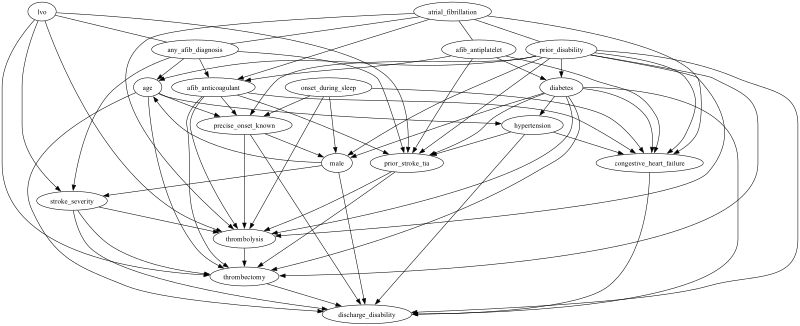

In [ ]:
nodes = [GraphNode(name) for name in feature_names]

pre_treatment_features = [
    'age',
    'male',
    'precise_onset_known',
    'onset_during_sleep',
    'lvo',
    'congestive_heart_failure',
    'hypertension',
    'atrial_fibrillation',
    'diabetes',
    'prior_stroke_tia',
    'afib_anticoagulant',
    'afib_antiplatelet',
    'any_afib_diagnosis',
    'prior_disability',
    'stroke_severity',
]

# Set ip background knowledge
bk = BackgroundKnowledge()

# Convert node list to name->node lookup so string indexing works
nodes = {name: node for name, node in zip(feature_names, nodes)}

# Avoid adding forbidden edges from outcome to any other feature
for col in feature_names:
    if col != "discharge_disability":
        bk.add_forbidden_by_node(nodes["discharge_disability"], nodes[col])

# Avoid forbidden edges from stroke severity, thrombolysis and thrombectomy to pre-treatment features
for col in pre_treatment_features:
    bk.add_forbidden_by_node(nodes["stroke_severity"], nodes[col])
    bk.add_forbidden_by_node(nodes["thrombolysis"], nodes[col])
    bk.add_forbidden_by_node(nodes["thrombectomy"], nodes[col])

# Add other known edges based on domain knowledge (this only forces direction, if a relationship is found)
bk.add_required_by_node(nodes["atrial_fibrillation"], nodes["afib_anticoagulant"])
bk.add_required_by_node(nodes["stroke_severity"], nodes["thrombolysis"])
bk.add_required_by_node(nodes["stroke_severity"], nodes["thrombectomy"])
bk.add_required_by_node(nodes["lvo"], nodes["thrombectomy"])
bk.add_required_by_node(nodes["prior_disability"], nodes["discharge_disability"])
bk.add_required_by_node(nodes["stroke_severity"], nodes["discharge_disability"])
bk.add_required_by_node(nodes["thrombolysis"], nodes["discharge_disability"])
bk.add_required_by_node(nodes["thrombectomy"], nodes["discharge_disability"])

# Add other forbidden edges based on domain knowledge
bk.add_forbidden_by_node(nodes["lvo"], nodes["age"])
bk.add_forbidden_by_node(nodes["lvo"], nodes["male"])
bk.add_forbidden_by_node(nodes["thrombectomy"], nodes["thrombolysis"])

# Convert data to numpy array for causal discovery
data_np = data.to_numpy(dtype=float)

cg_bk = pc(data_np, alpha=0.05, node_names=feature_names, background_knowledge=bk, show_progress=False)


# Display
pyd_small = GraphUtils.to_pydot(cg_bk.G)
pyd_small.set_size("4,3!")
Image(data=pyd_small.create_png(), width=350)

Notes:

* To include ASPECTS score, filter to when ASPECTS score is present

---------------------------------------------------------------------------
NameError                                 Traceback (most recent call last)
Cell In[10], line 5
      1 # Visualise with actual feature names
      2 pdy = GraphUtils.to_pydot(g, labels=feature_names)
      3 tmp_png = pdy.create_png(f="png")
      4 fp = io.BytesIO(tmp_png)
----> 5 img = mpimg.imread(fp, format='png')
      6 
      7 plt.figure(figsize=(12, 8))
      8 plt.axis('off')

NameError: name 'mpimg' is not defined